In [7]:
import numpy as np
import matplotlib . pyplot as plt
from scipy . optimize import minimize
import os
from matplotlib.colors import LogNorm
import seaborn as sns
import pandas as pd
import matplotlib.lines as mlines

from pprint import pprint
from scipy.interpolate import griddata


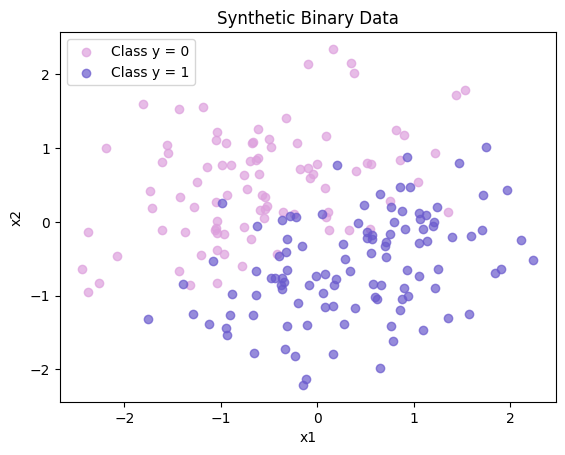

In [8]:
# Synthetic data
np.random.seed(2025)
n, p = 200, 2
X = np.random.randn(n, p)
true_w = np.array([2.0, -3.0])
logits = X @ true_w
prob = 1 / (1 + np.exp(-logits))
y = (np.random.rand(n) < prob).astype(float)

# plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
# plt.title("Synthetic binary data")
# plt.xlabel("x1")
# plt.ylabel("x2")
# plt.show()

# Plot points for each class separately
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="plum", label="Class y = 0", alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="slateblue", label="Class y = 1", alpha=0.7)

plt.title("Synthetic Binary Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc='upper left')
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "synthetic_data.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()

In [9]:
# Objective, gradient, and Hessian (stable)

def sigmoid(z):
    # Stable sigmoid (piecewise)
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def softplus(t):
    out = np.empty_like(t)
    big = t > 0
    out[big] = t[big] + np.log1p(np.exp(-t[big]))
    out[~big] = np.log1p(np.exp(t[~big]))
    return out

def f(w, X, y):
    z = X @ w
    return np.mean(softplus(z) - y * z)

def grad(w, X, y):
    z = X @ w
    return X.T @ (sigmoid(z) - y) / len(y)

def hess(w, X, y):
    z = X @ w
    S = sigmoid(z) * (1.0 - sigmoid(z))
    return (X.T * S) @ X / len(y)

In [10]:
# Gradient descent (fixed step) and Newton’s method (with backtracking)

def gradient_descent_logistic(X, y, stepsize=0.2, epsilon=1e-6, max_iters=20000):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'w': []}
    for _ in range(max_iters):
        g = grad(w, X, y)
        w_new = w - stepsize * g

        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['w'].append(w.copy())

        if np.linalg.norm(w_new - w) <= epsilon * max(1.0, np.linalg.norm(w)):
            w = w_new
            break
        w = w_new

    history['w'].append(w.copy())
    return w, history


def newton_method(X, y, T=50, tol=1e-10, alpha=0.25, beta=0.5, reg=0.0):
    w = np.zeros(X.shape[1])
    history = {'obj': [], 'norm_g': [], 'step': [], 'w': [], 'direction': []}

    for _ in range(T):
        g = grad(w, X, y)
        H = hess(w, X, y)
        if reg > 0:
            H = H + reg * np.eye(X.shape[1])

        try:
            s = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            H = H + 1e-6 * np.eye(X.shape[1])
            s = np.linalg.solve(H, -g)

        t = 1.0
        f_curr = f(w, X, y)

        # backtracking line search
        while True:
            w_try = w + t * s
            if f(w_try, X, y) <= f_curr + alpha * t * g.dot(s):
                break
            t *= beta
            if t < 1e-12:
                break

        w = w + t * s

        history['obj'].append(f(w, X, y))
        history['norm_g'].append(np.linalg.norm(g))
        history['step'].append(t)
        history['w'].append(w.copy())
        history['direction'].append(s.copy())

        if np.linalg.norm(g) < tol:
            break

    return w, history

# Write a BFGS function that records 



def fit_bfgs(X, y, w0=None, maxiter=200):
    if w0 is None:
        w0 = np.zeros(X.shape[1])

    history = {"obj": [], "norm_g": [], "w": []}

    def obj_wrap(w):
        return f(w, X, y)

    def grad_wrap(w):
        return grad(w, X, y)

    def callback(wk):
        history["w"].append(wk.copy())
        history["obj"].append(f(wk, X, y))
        history["norm_g"].append(np.linalg.norm(grad(wk, X, y)))

    res = minimize(
        obj_wrap,
        w0,
        jac=grad_wrap,
        method="BFGS",
        callback=callback,
        options={"gtol": 1e-10, "maxiter": maxiter},
    )

    if not history["w"] or not np.allclose(history["w"][-1], res.x):
        history["w"].append(res.x.copy())
        history["obj"].append(f(res.x, X, y))
        history["norm_g"].append(np.linalg.norm(grad(res.x, X, y)))

    return res.x, history

In [11]:
#run all the methods
w_gd, hist_gd = gradient_descent_logistic(X, y)
w_newton, hist_newton = newton_method(X, y)
w_bfgs, hist_bfgs = fit_bfgs(X, y)


print("True w:", true_w)
print("GD estimate:", w_gd)
print("Newton estimate:", w_newton)
print("BFGS estimate:", w_bfgs)


True w: [ 2. -3.]
GD estimate: [ 2.70899588 -4.20292781]
Newton estimate: [ 2.7104343  -4.20535123]
BFGS estimate: [ 2.7104343  -4.20535123]


In [16]:
# Fit all three methods
w_gd, hist_gd = gradient_descent_logistic(
    X, y, stepsize=0.2, epsilon=1e-8, max_iters=20000
)
w_newton, hist_newton = newton_method(
    X, y, T=50, tol=1e-10, alpha=0.25, beta=0.5, reg=0.0
)
w_bfgs, hist_bfgs = fit_bfgs(X, y, maxiter=10000)

print("GD weights:", w_gd)
print("Newton weights:", w_newton)
print("BFGS weights:", w_bfgs)

GD weights: [ 2.71041989 -4.20532696]
Newton weights: [ 2.7104343  -4.20535123]
BFGS weights: [ 2.7104343  -4.20535123]


GD weights: [ 0.04802077 -0.05595374]
Newton weights: [ 0.94177209 -1.36137533]
BFGS weights: [ 2.7104343  -4.20535123]


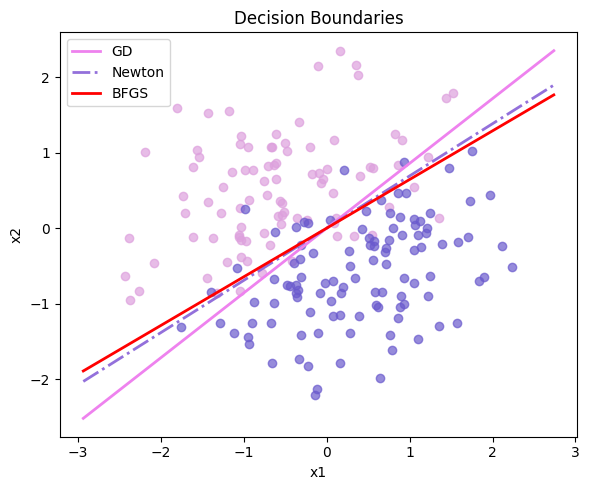

In [20]:

# Fit all three methods
w_gd, hist_gd = gradient_descent_logistic(
    X, y, stepsize=0.2, epsilon=1e-1, max_iters=20000
)


w_newton, hist_newton = newton_method(
    X, y, T=50, tol=100, alpha=0.25, beta=0.5, reg=0.0
)
w_bfgs, hist_bfgs = fit_bfgs(X, y, maxiter=10000)

print("GD weights:", w_gd)
print("Newton weights:", w_newton)
print("BFGS weights:", w_bfgs)

# Plot decision boundaries
plt.figure(figsize=(6, 5))

# data
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="plum", alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="slateblue", alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundaries")

# draw lines x2 = -(w1/w2) x1  (no intercept case)
x1_grid = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)

# def plot_boundary(w, label, style):
#     if abs(w[1]) < 1e-12:
#         return  # avoid divide-by-zero
#     x2_grid = -(w[0] / w[1]) * x1_grid
#     plt.plot(x1_grid, x2_grid, style, label=label)

# plot_boundary(w_gd, "GD", "b--")
# plot_boundary(w_newton, "Newton", "m-.")
# plot_boundary(w_bfgs, "BFGS", "r-")

def plot_boundary(w, label, color, linestyle):
    if abs(w[1]) < 1e-12:
        return  # avoid divide-by-zero
    x2_grid = -(w[0] / w[1]) * x1_grid
    plt.plot(x1_grid, x2_grid, color=color, linestyle=linestyle, linewidth=2, label=label)
plot_boundary(w_gd, "GD", color="violet", linestyle="-")
plot_boundary(w_newton, "Newton", color="mediumpurple", linestyle="-.")
plot_boundary(w_bfgs, "BFGS", color="red", linestyle="-")

plt.legend()
plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "combined_decision_boundary.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()

In [22]:
# --- Run BFGS for just a few iterations to capture early behavior ---
w_bfgs, bfgs_hist_short, = fit_bfgs(X, y, maxiter=3)

# Extract BFGS iterate sequence: θ_0, θ_1, θ_2, θ_3
thetas = np.array(bfgs_hist_short["w"])

# Compute BFGS step directions: d_k = θ_{k+1} − θ_k for k = 0,1,2
d_bfgs = [thetas[k+1] - thetas[k] for k in range(3)]

# Compute Newton directions at same iterates
d_newton = []
for k in range(3):
    w_k = thetas[k]
    g_k = grad(w_k, X, y)
    H_k = hess(w_k, X, y)
    # Solve Newton system
    p_k = -np.linalg.solve(H_k, g_k)
    d_newton.append(p_k)

# Cosine similarity & norm ratios
def cosine_similarity(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

cos_sim = [cosine_similarity(d_bfgs[k], d_newton[k]) for k in range(3)]
norm_ratio = [np.linalg.norm(d_bfgs[k]) / np.linalg.norm(d_newton[k]) for k in range(3)]

# ---- Print Table ----
print("k | BFGS direction d_BFGS | Newton direction d_Newton | cos_sim | ||d_BFGS||/||d_Newton||")
print("-"*95)
for k in range(3):
    print(f"{k} | {d_bfgs[k]} | {d_newton[k]} | {cos_sim[k]:.4f} | {norm_ratio[k]:.4f}")

# ---- Quiver plot in 2D parameter space ----
fig, ax = plt.subplots()
for k in range(3):
    w_k = thetas[k]
    ax.quiver(w_k[0], w_k[1], d_bfgs[k][0], d_bfgs[k][1], angles='xy', scale_units='xy', scale=1,
              label=f"BFGS step {k}", alpha=0.6)
    ax.quiver(w_k[0], w_k[1], d_newton[k][0], d_newton[k][1], angles='xy', scale_units='xy', scale=1,
              color='black', linestyle='dashed', alpha=0.9,
              label=f"Newton step {k}" if k==0 else "")

ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_title("Early-step BFGS vs Newton Directions")
ax.legend()
ax.grid(True)
plt.axis("equal")
plt.show()

IndexError: index 3 is out of bounds for axis 0 with size 3

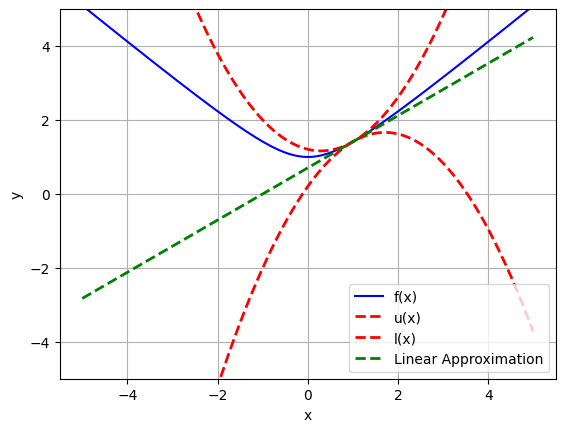

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sqrt(1 + x**2)

def df(x):
    return x / np.sqrt(1 + x**2)

L = 1
x0 = 1

def u(x):
    return f(x0) + df(x0) * (x - x0) + (L / 2) * (x - x0)**2

def l(x):
    return f(x0) + df(x0) * (x - x0) - (L / 2) * (x - x0)**2

xvals = np.arange(-5, 5, 0.01)

plt.plot(xvals, f(xvals), 'b-', label='f(x)')
plt.plot(xvals, u(xvals), 'r--', label='u(x)', linewidth=2)
plt.plot(xvals, l(xvals), 'r--', label='l(x)', linewidth=2)
plt.plot(xvals, f(x0) + (xvals - x0) * df(x0), 'g--', label='Linear Approximation', linewidth=2)

plt.ylim(-5, 5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()